<a href="https://colab.research.google.com/github/annikulkarni/APS/blob/main/micro_Grad_practice_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [190]:
class myNode:
  def __init__(self, val,_children=(),_op = '',_backward = lambda: None):
    self.val = val
    self.grad = 0.0
    self._prev = set(_children)
    self._op = _op
    self._backward = _backward

  def __add__(self,other):
    if not isinstance(other,myNode):
      other = myNode(other)
    out = myNode(self.val + other.val,(self,other),'+')
    def _backward():
      self.grad+= 1.0 * out.grad
      other.grad+= 1.0 * out.grad
    out._backward = _backward
    return out

  def __rmul__(self, other):
        return self.value * other

  def __mul__(self,other):
    if not isinstance(other,myNode):
      other = myNode(other)
    out = myNode(self.val * other.val,(self,other),'*')
    def _backward():
      self.grad += other.val * out.grad
      other.grad += self.val * out.grad
    out._backward = _backward
    return out

  def build_backward(self):
    topo = []
    vis = set()
    def build_topo(self):
      if self not in vis:
        vis.add(self)
        for child in self._prev:
          # print(f"child: {child.val}")
          build_topo(child)
        # print(f"Appending node: {self.val}")
        topo.append(self)
    build_topo(self)

    self.grad = 1.0

    for node in reversed(topo):
      print(node.val)
      node._backward()



  def _show_(self):
    print('value' ,self.val)
    print('grad' ,self.grad)



In [191]:
import graphviz as gr

G = gr.Digraph()
G.attr(rankdir='LR')

vis = []
nodes = []
visitedNodes = []

def build_graph(root):
    if(root._prev!=set()):
      op_node_id = str(id(root)) + root._op
      if root not in vis:
        vis.append(root)
        G.node(op_node_id, label=f"{{{str(root._op)}}}",shape = 'record')
        root._show_()
        G.node(str(id(root)), label=f"{{{str(id(root))}|val: {root.val} | grad: {root.grad} }}",shape = 'record')
      for child in root._prev:
        # child._show_()
        build_graph(child)
        G.node(str(id(child)), label=f"{{{str(id(child))}|val: {child.val} | grad: {child.grad} }}",shape = 'record')
        G.edge(str(id(child)),op_node_id)
      G.edge(op_node_id,str(id(root)))

    return G


value 7.800000000000001
grad 1.7
value 15.81
grad 1.0
value 9.3
grad 1.7
value 7.800000000000001
grad 1.7
value 5.4
grad 1.7


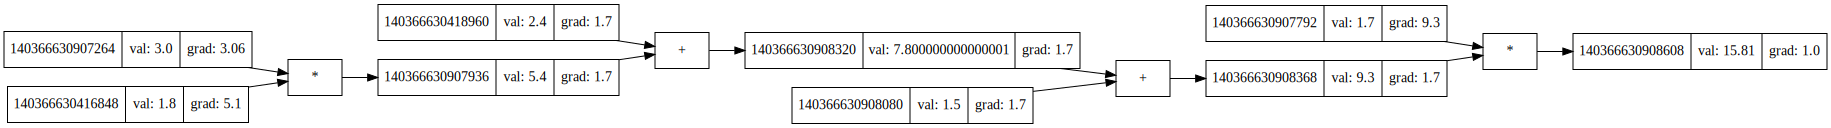

In [ ]:


a = myNode(2.4)
a.label = 'a'
b = myNode(1.8)
b.label = 'b'
c = myNode(3.0)
c.label = 'c'
e = myNode(1.5)
i = myNode(1.7)

d = b * c + a
f = d + e
g = f * i


# g.grad = 1.0
g.build_backward()



d.label = 'd'
d._show_()
G = build_graph(g)
G



In [ ]:
import torch

In [ ]:
a = torch.Tensor([2.4]).double() ; a.requires_grad = True
b = torch.Tensor([1.8]).double() ; b.requires_grad = True
c = torch.Tensor([3.0]).double() ; c.requires_grad = True
e = torch.Tensor([1.5]).double() ; e.requires_grad = True
i = torch.Tensor([1.7]).double() ; i.requires_grad = True

d = b*c + a
f = d+e
g = f*i
g.backward()
print(g.data.item())
print(c.grad.item())

15.810000362396238
3.0600000047683693


[<__main__.myNode object at 0x7fa9740a85f0>, <__main__.myNode object at 0x7fa9740a9370>]
2.32289757657536
1.068005883933931
0.7120039226226207
1.5
1.2548916926414289
-0.10995894200069856
1.3648506346421274
0.6824253173210637
2.0
value 2.32289757657536
grad 1.0
value 1.2548916926414289
grad 1.0
value 1.3648506346421274
grad 1.0
value 1.068005883933931
grad 1.0


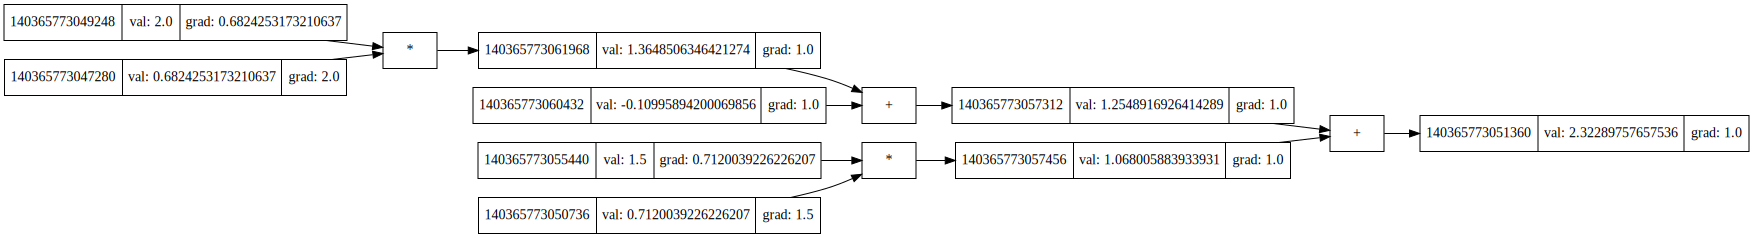

In [192]:
from IPython.core.formatters import IPythonDisplayFormatter
import random
class Neuron:
  def __init__(self,n):
    self.w = [myNode(random.uniform(-1,1)) for _ in range(n)]
    print(self.w)
    self._b = myNode(random.uniform(-1,1))
  def __call__(self,x):
    inter = sum((wi*item for wi,item in zip(self.w,x)),self._b)
    return inter

class Layer():
  def __init__(self,nin,nouts):
    self.neurons = [Neuron(nin) for _ in range(nouts)]
  def __call__(self,x):
    outs = [n(x) for neuron in self.neurons]
    return outs





x = [2.0,1.5]
a = Neuron(2)
output = a(x)
output.build_backward()

G1 = build_graph(output)

G1

# a = Layer(2,3)
# a(x)



